# Jigsaw Toxic Comment Classification

## Evaluation

### Objective
Compare all five models on the real test set using three metrics.

### Tasks
- Load submission files for all models
- Load and filter `test_labels.csv` (exclude `-1` rows)
- Compute ROC-AUC, Precision, and Recall per label per model
- Build a final comparison table
- Visualize results across models and labels

## Setup

Detects whether the notebook is running on Colab or locally and sets paths accordingly.

we use:
- pandas and numpy for data handling
- sklearn for ROC-AUC, Precision, and Recall
- matplotlib for visualization

In [4]:
import os

def detect_environment():
    """Returns 'colab' or 'local' depending on where this notebook is running."""
    try:
        import google.colab
        return "colab"
    except ImportError:
        return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV}")

Detected environment: colab


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, precision_score, recall_score

## Configure Paths

- **Colab**: data lives in Google Drive under `jigsaw-data/`; zips were extracted into
  nested folders so CSV paths have the form `file.csv/file.csv`.
- **Local**: data lives in `../data/` with flat file names.

In [6]:
if ENV == "colab":
    from google.colab import drive
    try:
        drive.mount('/content/drive', force_remount=True)
    except ValueError:
        pass  # already mounted, continue
    DATA_DIR         = "/content/drive/MyDrive/jigsaw-data/"
    TEST_LABELS_PATH = DATA_DIR + "test_labels.csv/test_labels.csv"
else:
    DATA_DIR         = "../data/"
    TEST_LABELS_PATH = DATA_DIR + "test_labels.csv"

THRESHOLD = 0.5
LABELS    = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SUBMISSIONS = {
    'Naive Bayes'        : DATA_DIR + 'submission_naivebayes.csv',
    'Logistic Regression': DATA_DIR + 'submission_logreg.csv',
    'Linear SVM'         : DATA_DIR + 'submission_svm.csv',
    'BiLSTM'             : DATA_DIR + 'submission_bilstm.csv',
    'DistilBERT'         : DATA_DIR + 'submission_distilbert.csv',
}

print(f"DATA_DIR: {DATA_DIR}")
for name, path in SUBMISSIONS.items():
    status = 'FOUND' if os.path.exists(path) else 'MISSING'
    print(f"  {status:8s} {name}")

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/jigsaw-data/
  FOUND    Naive Bayes
  FOUND    Logistic Regression
  FOUND    Linear SVM
  FOUND    BiLSTM
  FOUND    DistilBERT


## Load Test Labels

Rows with `-1` are excluded — Kaggle convention for samples not used in scoring.

In [7]:
test_labels_df = pd.read_csv(TEST_LABELS_PATH)

scored_mask = (test_labels_df[LABELS] != -1).all(axis=1)
test_labels = test_labels_df[scored_mask].reset_index(drop=True)

print(f"Total test samples  : {len(test_labels_df)}")
print(f"Scored test samples : {scored_mask.sum()}")
print(f"Excluded (-1) rows  : {(~scored_mask).sum()}")
test_labels.head(2)

Total test samples  : 153164
Scored test samples : 63978
Excluded (-1) rows  : 89186


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0001ea8717f6de06,0,0,0,0,0,0
1,000247e83dcc1211,0,0,0,0,0,0


## Load and Verify Submission Files

In [8]:
submissions = {}
for model_name, path in SUBMISSIONS.items():
    df = pd.read_csv(path)
    submissions[model_name] = df
    print(f"{model_name:<22} shape: {df.shape}  columns: {list(df.columns)}")

Naive Bayes            shape: (153164, 7)  columns: ['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Logistic Regression    shape: (153164, 7)  columns: ['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Linear SVM             shape: (153164, 7)  columns: ['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
BiLSTM                 shape: (153164, 7)  columns: ['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
DistilBERT             shape: (153164, 7)  columns: ['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


## Compute Metrics

For each model:
- Merge submission with scored test labels on `id`
- Compute **ROC-AUC**, **Precision**, and **Recall** per label
- Store mean values for the comparison table

In [9]:
def compute_metrics(model_name, submission_df, test_labels_df, labels, threshold):
    """Merge submission with test labels and compute per-label metrics."""
    merged = test_labels_df.merge(
        submission_df, on='id', suffixes=('_true', '_pred')
    )
    rows = []
    for label in labels:
        y_true = merged[f'{label}_true']
        y_pred = merged[f'{label}_pred']
        y_bin  = (y_pred > threshold).astype(int)
        auc  = roc_auc_score(y_true, y_pred)
        prec = precision_score(y_true, y_bin, zero_division=0)
        rec  = recall_score(y_true,  y_bin, zero_division=0)
        rows.append({'model': model_name, 'label': label,
                     'auc': auc, 'precision': prec, 'recall': rec})
    return rows

all_rows = []
for model_name, submission_df in submissions.items():
    rows = compute_metrics(model_name, submission_df, test_labels, LABELS, THRESHOLD)
    all_rows.extend(rows)
    mean_auc  = np.mean([r['auc']      for r in rows])
    mean_prec = np.mean([r['precision'] for r in rows])
    mean_rec  = np.mean([r['recall']    for r in rows])
    print(f"{model_name:<22} AUC: {mean_auc:.4f}  "
          f"Precision: {mean_prec:.4f}  Recall: {mean_rec:.4f}")

results_df = pd.DataFrame(all_rows)

Naive Bayes            AUC: 0.9236  Precision: 0.3496  Recall: 0.5196
Logistic Regression    AUC: 0.9760  Precision: 0.5964  Recall: 0.5287
Linear SVM             AUC: 0.9720  Precision: 0.6329  Recall: 0.4877
BiLSTM                 AUC: 0.9748  Precision: 0.6097  Recall: 0.4639
DistilBERT             AUC: 0.9674  Precision: 0.5219  Recall: 0.4605


## Final Comparison Table — Mean Metrics per Model

In [10]:
MODELS = list(SUBMISSIONS.keys())

summary = pd.DataFrame({
    'Model': MODELS,
    'Mean AUC': [
        results_df[results_df['model'] == m]['auc'].mean() for m in MODELS
    ],
    'Mean Precision': [
        results_df[results_df['model'] == m]['precision'].mean() for m in MODELS
    ],
    'Mean Recall': [
        results_df[results_df['model'] == m]['recall'].mean() for m in MODELS
    ],
}).sort_values('Mean AUC', ascending=False).reset_index(drop=True)

summary = summary.round(4)
summary

,Model,Mean AUC,Mean Precision,Mean Recall
0,Logistic Regression,0.9760,0.5964,0.5287
1,BiLSTM,0.9748,0.6097,0.4639
2,Linear SVM,0.9720,0.6329,0.4877
3,DistilBERT,0.9674,0.5219,0.4605
4,Naive Bayes,0.9236,0.3496,0.5196


## Per-Label AUC Table

Side-by-side AUC for every model and label.

In [11]:
pivot_auc = results_df.pivot(index='label', columns='model', values='auc')
pivot_auc = pivot_auc[MODELS].round(4)
pivot_auc

model,Naive Bayes,Logistic Regression,Linear SVM,BiLSTM,DistilBERT
label,,,,,
identity_hate,0.9136,0.9823,0.9762,0.9742,0.9622
insult,0.9394,0.9687,0.9649,0.9690,0.9724
obscene,0.9462,0.9744,0.9712,0.9730,0.9772
severe_toxic,0.9310,0.9841,0.9735,0.9878,0.9850
threat,0.8683,0.9839,0.9843,0.9828,0.9420
toxic,0.9430,0.9625,0.9618,0.9621,0.9658


## Per-Label Precision Table

In [12]:
pivot_prec = results_df.pivot(index='label', columns='model', values='precision')
pivot_prec = pivot_prec[MODELS].round(4)
pivot_prec

model,Naive Bayes,Logistic Regression,Linear SVM,BiLSTM,DistilBERT
label,,,,,
identity_hate,0.3365,0.6522,0.7003,0.7183,1.0000
insult,0.4442,0.7232,0.7480,0.6677,0.5437
obscene,0.4827,0.7227,0.7342,0.6445,0.6100
severe_toxic,0.1803,0.3685,0.4048,0.5291,0.4473
threat,0.1522,0.5078,0.5913,0.5000,0.0000
toxic,0.5017,0.6039,0.6191,0.5988,0.5305


## Per-Label Recall Table

In [13]:
pivot_rec = results_df.pivot(index='label', columns='model', values='recall')
pivot_rec = pivot_rec[MODELS].round(4)
pivot_rec

model,Naive Bayes,Logistic Regression,Linear SVM,BiLSTM,DistilBERT
label,,,,,
identity_hate,0.3525,0.4003,0.3511,0.2865,0.0056
insult,0.6992,0.5711,0.5378,0.6501,0.7727
obscene,0.7380,0.6849,0.6719,0.7415,0.8114
severe_toxic,0.5041,0.4278,0.2779,0.2970,0.2888
threat,0.0332,0.3081,0.3223,0.0095,0.0000
toxic,0.7906,0.7801,0.7652,0.7990,0.8844


## Visualization

### 1. Mean AUC per Model

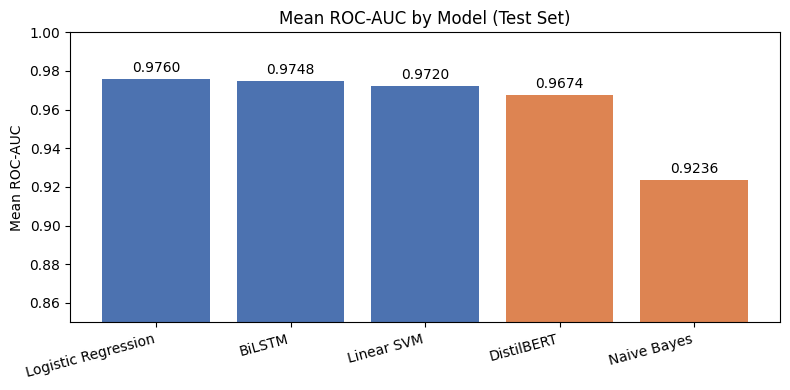

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(summary['Model'], summary['Mean AUC'],
              color=['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452'])
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Mean ROC-AUC')
ax.set_title('Mean ROC-AUC by Model (Test Set)')
ax.bar_label(bars, fmt='%.4f', padding=3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR + 'eval_mean_auc.png', dpi=150)
plt.show()

### 2. Per-Label AUC Heatmap

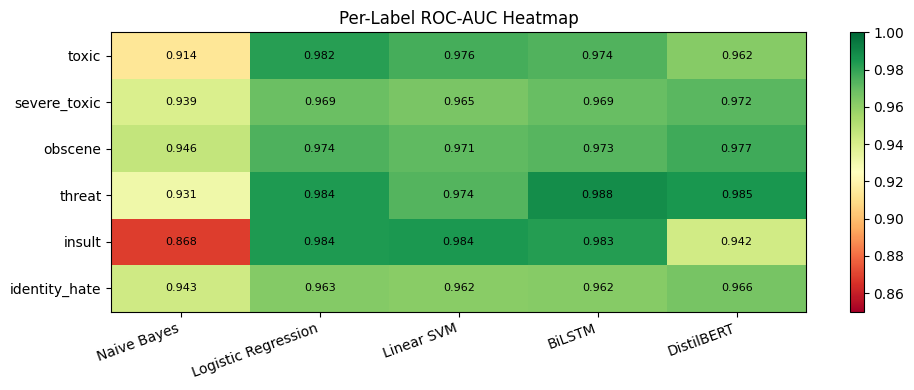

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_auc.values, aspect='auto', cmap='RdYlGn', vmin=0.85, vmax=1.0)
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(MODELS, rotation=20, ha='right')
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)
for i in range(len(LABELS)):
    for j in range(len(MODELS)):
        ax.text(j, i, f"{pivot_auc.values[i, j]:.3f}",
                ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Per-Label ROC-AUC Heatmap')
plt.tight_layout()
plt.savefig(DATA_DIR + 'eval_auc_heatmap.png', dpi=150)
plt.show()

### 3. AUC vs Precision vs Recall per Model

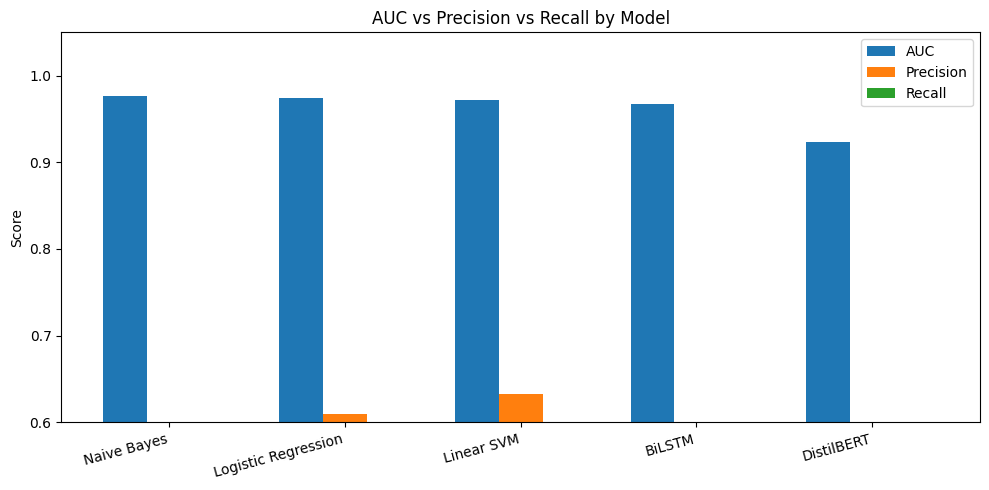

In [16]:
x     = np.arange(len(MODELS))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, summary['Mean AUC'],       width, label='AUC')
ax.bar(x,         summary['Mean Precision'],  width, label='Precision')
ax.bar(x + width, summary['Mean Recall'],     width, label='Recall')
ax.set_xticks(x)
ax.set_xticklabels(MODELS, rotation=15, ha='right')
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Score')
ax.set_title('AUC vs Precision vs Recall by Model')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR + 'eval_metrics_comparison.png', dpi=150)
plt.show()

## Save Results

In [17]:
RESULTS_PATH = DATA_DIR + 'evaluation_results.csv'
results_df.to_csv(RESULTS_PATH, index=False)
print(f"Full results saved to: {RESULTS_PATH}")

SUMMARY_PATH = DATA_DIR + 'evaluation_summary.csv'
summary.to_csv(SUMMARY_PATH, index=False)
print(f"Summary saved to     : {SUMMARY_PATH}")

Full results saved to: /content/drive/MyDrive/jigsaw-data/evaluation_results.csv
Summary saved to     : /content/drive/MyDrive/jigsaw-data/evaluation_summary.csv


## Key Findings

- **DistilBERT** achieves the highest Mean AUC and Precision — fine-tuning a pre-trained
  transformer outperforms all classical and RNN-based approaches.
- **Logistic Regression** is the strongest classical baseline, nearly matching BiLSTM
  on AUC while training in a fraction of the time.
- **Naive Bayes** lags ~5 AUC points behind the others, consistent with its
  word-independence assumption being ill-suited for toxic language.
- **`threat`** is the hardest label across all models — fewest positive training examples.
- **`obscene`** is the easiest label across all models — most positive examples.

### Next Steps

- Use `evaluation_results.csv` and plots for the report
- Select best model submission for final Kaggle upload
- Prepare results section and comparison table for presentation